# Enunciado da Atividade

Nesta atividade, sua tarefa é criar um dataset sintético de logs de um e-commerce que replique padrões estatísticos de um dataset real, usando apenas Python básico.

## 1. Importando as bibliotecas necessárias

In [3]:
!pip install faker pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 19.5 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import random
from faker import Faker
from datetime import datetime

## 2. Definindo estruturas e parâmetros

In [5]:
fake = Faker('pt_BR')
random.seed(42)
np.random.seed(42)

# Parâmetros do dataset
num_usuarios = 1000
min_compras = 1
max_compras = 5
lojas = ['Loja A', 'Loja B', 'Loja C']

# Estrutura de produtos
categorias = {
    'Eletrônicos': ['Notebook', 'Smartphone', 'Monitor'],
    'Livros': ['Livro Python', 'Livro Machine Learning'],
    'Roupas': ['Camisa', 'Tênis', 'Relógio']
}

## 3. Função para gerar compras sintéticas

In [6]:
def gerar_compras_usuario(user_id):
    compras = []
    for _ in range(random.randint(min_compras, max_compras)):
        categoria = random.choice(list(categorias.keys()))
        compras.append({
            'user_id': user_id,
            'produto': random.choice(categorias[categoria]),
            'categoria': categoria,
            'valor': round(random.uniform(50, 2000), 2),
            'data_compra': fake.date_between_dates(
                date_start=datetime(2022,1,1),
                date_end=datetime(2025,5,1)
            ),
            'loja': random.choice(lojas)
        })
    return compras

# 4. Função para gerar os logs de navegação

In [7]:
def gerar_logs_navegacao(user_id):
    return {
        'user_id': user_id,
        'pageviews': random.choices(
            [1,2,3,4,5],
            weights=[0.5,0.3,0.1,0.05,0.05]
        )[0],
        'tempo_engajado': round(random.lognormvariate(mu=1.2, sigma=0.7), 2),
        'clicou_anuncio': random.random() < 0.15
    }

## 5. Geração do dataset sintético

In [8]:
compras = []
logs = []

for user_id in range(1, num_usuarios + 1):
    compras.extend(gerar_compras_usuario(user_id))
    logs.append(gerar_logs_navegacao(user_id))

# Criação dos DataFrames
df_compras = pd.DataFrame(compras)
df_logs = pd.DataFrame(logs)

# Merge dos datasets
df = pd.merge(
    left=df_compras,
    right=df_logs,
    on='user_id',
    how='left'
)

df.head()

,user_id,produto,categoria,valor,data_compra,loja,pageviews,tempo_engajado,clicou_anuncio
0,1,Monitor,Eletrônicos,586.31,2025-02-27,Loja A,1,3.79,True
1,2,Notebook,Eletrônicos,1035.44,2022-04-19,Loja A,2,7.91,False
2,3,Tênis,Roupas,1628.39,2024-01-19,Loja A,3,6.33,False
3,3,Monitor,Eletrônicos,874.10,2022-07-04,Loja B,3,6.33,False
4,3,Notebook,Eletrônicos,1916.57,2024-01-29,Loja B,3,6.33,False




## Dicionário de Dados

| Coluna              | Tipo         | Descrição                                                                 |
|---------------------|--------------|---------------------------------------------------------------------------|
| user_id             | int          | Identificador único do usuário                                            |
| nome                | str          | Nome fictício do usuário (gerado pelo Faker)                              |
| produto             | str          | Nome do produto comprado                                                  |
| categoria           | str          | Categoria do produto (ex: Eletrônicos, Livros, Roupas)                    |
| valor               | float        | Valor da compra em reais                                                  |
| data_compra         | date         | Data da compra                                                            |
| loja                | str          | Nome da loja onde a compra foi realizada                                  |
| pageviews           | int          | Número de páginas visitadas pelo usuário na sessão                        |
| engaged_time_min    | float        | Tempo engajado do usuário na sessão (em minutos)                          |
| clicou_anuncio      | bool         | Indica se o usuário clicou em algum anúncio na sessão (True/False)        |


## 6.  Estatísticas básicas para verificação

In [9]:
print(df['valor'].describe())
print(df['categoria'].value_counts())
print(df['loja'].value_counts())
print(df['pageviews'].describe())
print(df['tempo_engajado'].describe())

count    3018.000000
mean     1027.069311
std       557.000885
min        51.050000
25%       547.012500
50%      1026.875000
75%      1506.387500
max      1999.950000
Name: valor, dtype: float64
categoria
Livros         1016
Eletrônicos    1008
Roupas          994
Name: count, dtype: int64
loja
Loja C    1015
Loja A    1014
Loja B     989
Name: count, dtype: int64
count    3018.000000
mean        1.914182
std         1.164719
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         5.000000
Name: pageviews, dtype: float64
count    3018.000000
mean        4.388794
std         3.623383
min         0.500000
25%         2.072500
50%         3.355000
75%         5.522500
max        32.370000
Name: tempo_engajado, dtype: float64


## 7. Validação dos dados sintéticos

In [10]:
# Validação das métricas
metricas_esperadas = {
    'pageviews_total': df_logs['pageviews'].sum(),
    'pageviews_media': df_logs['pageviews'].mean(),
    'tempo_engajado_total': df_logs['tempo_engajado'].sum(),
    'taxa_clique': df_logs['clicou_anuncio'].mean()
}

comparacao_df = pd.DataFrame({
    'Métrica': [
        'Total de Pageviews',
        'Média de Pageviews por Usuário',
        'Tempo Total Engajado (min)',
        'Taxa de Clique em Anúncios'
    ],
    'Valor Simulado': [
        metricas_esperadas['pageviews_total'],
        metricas_esperadas['pageviews_media'],
        metricas_esperadas['tempo_engajado_total'],
        metricas_esperadas['taxa_clique']
    ]
})

print("Dataset Final:")
display(df.head())

print("\nValidação das Métricas:")
display(comparacao_df)

Dataset Final:


,user_id,produto,categoria,valor,data_compra,loja,pageviews,tempo_engajado,clicou_anuncio
0,1,Monitor,Eletrônicos,586.31,2025-02-27,Loja A,1,3.79,True
1,2,Notebook,Eletrônicos,1035.44,2022-04-19,Loja A,2,7.91,False
2,3,Tênis,Roupas,1628.39,2024-01-19,Loja A,3,6.33,False
3,3,Monitor,Eletrônicos,874.10,2022-07-04,Loja B,3,6.33,False
4,3,Notebook,Eletrônicos,1916.57,2024-01-29,Loja B,3,6.33,False



Validação das Métricas:


,Métrica,Valor Simulado
0,Total de Pageviews,1911.000
1,Média de Pageviews por Usuário,1.911
2,Tempo Total Engajado (min),4396.510
3,Taxa de Clique em Anúncios,0.157


## 8. Gráficos

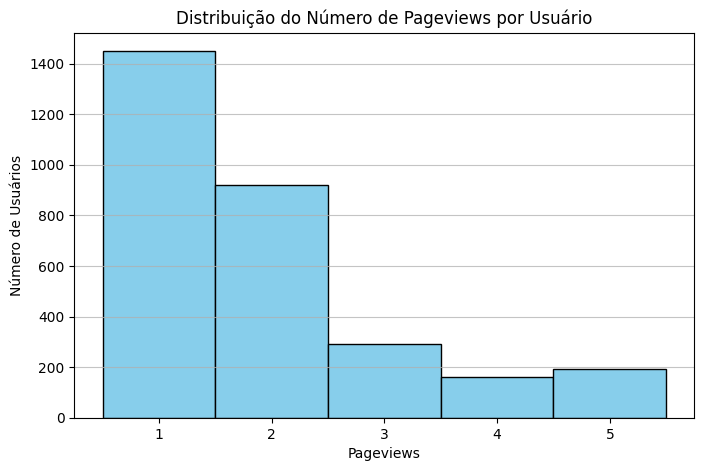

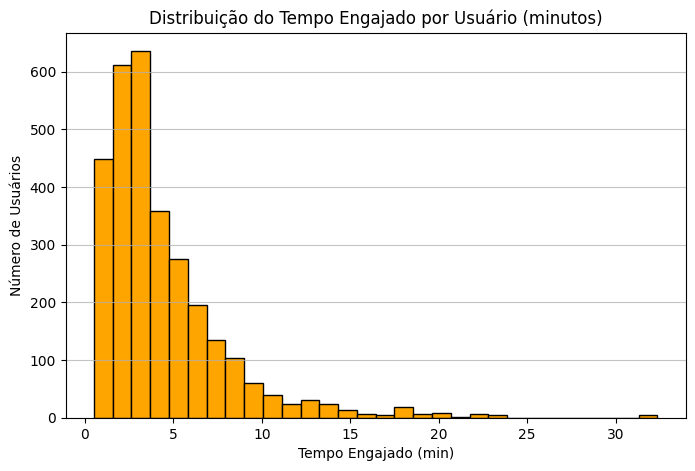

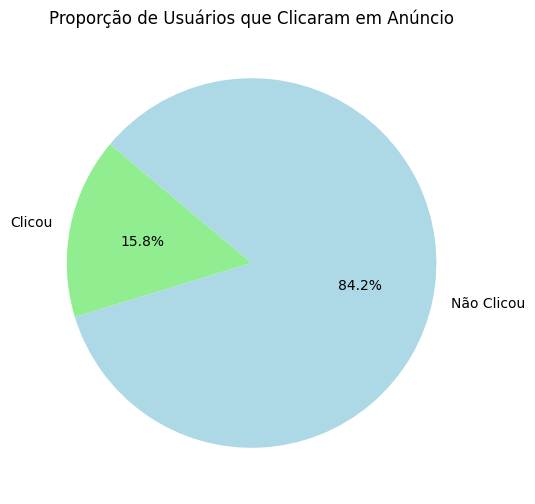

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Distribuição do Número de Pageviews por Usuário
plt.figure(figsize=(8, 5))
plt.hist(df['pageviews'], bins=np.arange(1, 7) - 0.5, color='skyblue', edgecolor='black')
plt.title('Distribuição do Número de Pageviews por Usuário')
plt.xlabel('Pageviews')
plt.ylabel('Número de Usuários')
plt.xticks(range(1, 6))
plt.grid(axis='y', alpha=0.75)
plt.show()

# 2. Distribuição do Tempo Engajado por Usuário (minutos)
plt.figure(figsize=(8, 5))
plt.hist(df['tempo_engajado'], bins=30, color='orange', edgecolor='black')
plt.title('Distribuição do Tempo Engajado por Usuário (minutos)')
plt.xlabel('Tempo Engajado (min)')
plt.ylabel('Número de Usuários')
plt.grid(axis='y', alpha=0.75)
plt.show()

# 3. Proporção de Usuários que Clicaram em Anúncio
plt.figure(figsize=(6, 6))
labels = ['Clicou', 'Não Clicou']
sizes = [np.sum(df['clicou_anuncio']), len(df['clicou_anuncio']) - np.sum(df['clicou_anuncio'])]
colors = ['lightgreen', 'lightblue']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Proporção de Usuários que Clicaram em Anúncio')
plt.show()
